# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
Index(['Unnamed: 0', 'Make', 'Ma

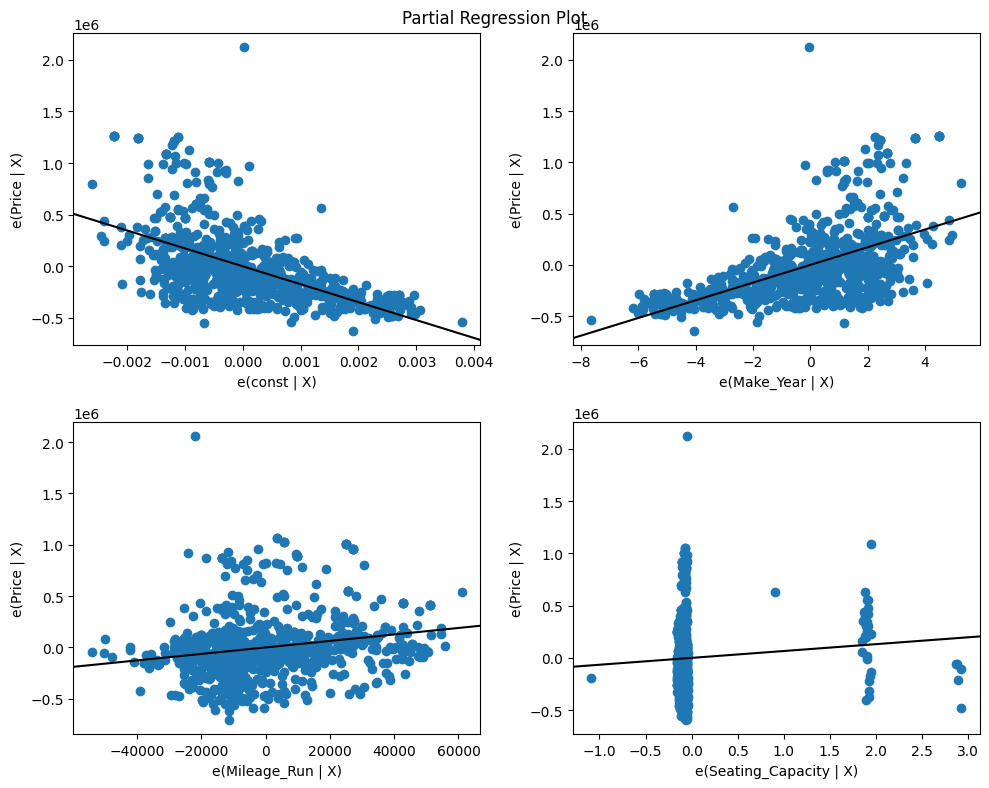

Train RMSE: 139717.82480448284
Test RMSE: 142716.44675353073
Train R2: 0.8601448123927014
Test R2: 0.8224168579717939


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("cars_hw.csv")
print(df.head())


#P1

print(df.columns)
print(df["No_of_Owners"].unique())

df = df.drop(columns=["Unnamed: 0"])

df.isna().sum()
# no missing values

df.dtypes

object_cols = df.select_dtypes(include='object').columns

for col in object_cols:
    col
    df[col].unique()
#correct formatting

df.describe()
#no outliers


#P2

df = pd.get_dummies(df, drop_first=True)

#P3

from sklearn.model_selection import train_test_split

y= df["Price"]
X = df.drop(columns=["Price"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#P4

#Numerical Variables Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

num_cols = ["Make_Year", "Mileage_Run", "Seating_Capacity"]

X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

num_model = LinearRegression()
num_model.fit(X_train_num, y_train)

y_train_pred_num = num_model.predict(X_train_num)
y_test_pred_num = num_model.predict(X_test_num)

rmse_train_num = np.sqrt(mean_squared_error(y_train, y_train_pred_num))
rmse_test_num = np.sqrt(mean_squared_error(y_test, y_test_pred_num))

r2_train_num = r2_score(y_train, y_train_pred_num)
r2_test_num = r2_score(y_test, y_test_pred_num)

print("Numerical Model")
print("Train RMSE:", rmse_train_num)
print("Test RMSE:", rmse_test_num)
print("Train R2:", r2_train_num)
print("Test R2:", r2_test_num)


cat_cols = [col for col in X_train.columns if col not in num_cols]

X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]

cat_model = LinearRegression()
cat_model.fit(X_train_cat, y_train)

y_train_pred_cat = cat_model.predict(X_train_cat)
y_test_pred_cat = cat_model.predict(X_test_cat)

rmse_train_cat = np.sqrt(mean_squared_error(y_train, y_train_pred_cat))
rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

r2_train_cat = r2_score(y_train, y_train_pred_cat)
r2_test_cat = r2_score(y_test, y_test_pred_cat)

print("Categorical Model")
print("Train RMSE:", rmse_train_cat)
print("Test RMSE:", rmse_test_cat)
print("Train R2:", r2_train_cat)
print("Test R2:", r2_test_cat)


#The categorical model performed much better than the numerical model because it had a much lower RMSE and a much higher R2 on both the training and test sets.


#P5

import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid

X_train_num_sm = sm.add_constant(X_train_num)
model_sm = sm.OLS(y_train, X_train_num_sm).fit()

fig = plt.figure(figsize=(10, 8))
plot_partregress_grid(model_sm, fig=fig)
plt.show()

#there appear to be some non-linearities, especially for Make_Year and Seating_Capacity.

#P6

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)

X_train_poly = pd.DataFrame(X_train_poly, index=X_train.index).astype(float)
X_test_poly = pd.DataFrame(X_test_poly, index=X_test.index).astype(float)

X_train_poly.columns = X_train_poly.columns.astype(str)
X_test_poly.columns = X_test_poly.columns.astype(str)
X_train_cat.columns = X_train_cat.columns.astype(str)
X_test_cat.columns = X_test_cat.columns.astype(str)

X_train_complex = pd.concat([X_train_poly, X_train_cat], axis=1)
X_test_complex = pd.concat([X_test_poly, X_test_cat], axis=1)

model = LinearRegression()
model.fit(X_train_complex, y_train)

train_pred = model.predict(X_train_complex)
test_pred = model.predict(X_test_complex)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

#P7
"""
The more complex model performed best, with the lowest RMSE and highest R2 on both
the training and test sets. This shows that the simpler numerical model underfit the data,
while adding categorical variables, interactions, and transformations improved the model without strong signs of overfitting.
"""